In [1]:
!kaggle datasets download -d unclesamulus/blood-cells-image-dataset -p /app/data --unzip

Dataset URL: https://www.kaggle.com/datasets/unclesamulus/blood-cells-image-dataset
License(s): CC-BY-SA-4.0
100%|████████████████████████████████████████| 268M/268M [00:07<00:00, 37.8MB/s]



In [8]:
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import math
import numpy as np
from PIL import Image
import random
import torch
import torchvision

# Data Exploratory Analysis

## Inventory and data integrty

In [2]:
ROOT = Path.cwd().parent
DATA_PATH = ROOT / "data" / "bloodcells_dataset"

### Inspect data directory

In [ ]:
# data dirrectory structure
for file in DATA_PATH.iterdir():
    print(file)

/app/data/bloodcells_dataset/neutrophil
/app/data/bloodcells_dataset/erythroblast
/app/data/bloodcells_dataset/platelet
/app/data/bloodcells_dataset/ig
/app/data/bloodcells_dataset/lymphocyte
/app/data/bloodcells_dataset/monocyte
/app/data/bloodcells_dataset/eosinophil
/app/data/bloodcells_dataset/basophil


### Verify file validity

In [108]:
zero_bit = []
mismatch = []
errors = []
formats = []

for type in DATA_PATH.iterdir():
    for image in type.iterdir():
        try:
            if image.stat().st_size == 0:
                zero_bit.append(image)
            with Image.open(image) as img:
                fmt = img.format
                img.load()

            formats.append(fmt)
            # check wether the file extention matches with the content type
            if fmt is None or fmt.lower() not in image.suffix.lower().replace("jpg", "jpeg"):
                mismatch.append((image, fmt, image.suffix))
        except Exception as e:
            errors.append((image, e)) 

formats = Counter(formats)

In [112]:
# no corrupted files
print("Empty files:", len(zero_bit))
print("wrong extension:", len(mismatch))
print("unreadable files:", len(errors))

Empty files: 0
wrong extension: 0
unreadable files: 0


In [ ]:
# All images are jpg/jpeg's
for format, count in formats.most_common():
    print(f"{format}: {count}")

JPEG: 17092


### Inspect instance count and class balance

In [212]:
# count blood cell types
types = []
for type in DATA_PATH.iterdir():
    for image in type.iterdir():
        types.append(type.name)
types = Counter(types)

In [213]:
print("instances per class:")
print("-"*30)
print(f"{'cell type':<20}| count")
print("-"*30)
for category, count in types.most_common():
    print(f"{category:<20}| {count}")
print("-"*30)
print(f"{'total':<20}| {types.total()}")

instances per class:
------------------------------
cell type           | count
------------------------------
neutrophil          | 3329
eosinophil          | 3117
ig                  | 2895
platelet            | 2348
erythroblast        | 1551
monocyte            | 1420
basophil            | 1218
lymphocyte          | 1214
------------------------------
total               | 17092


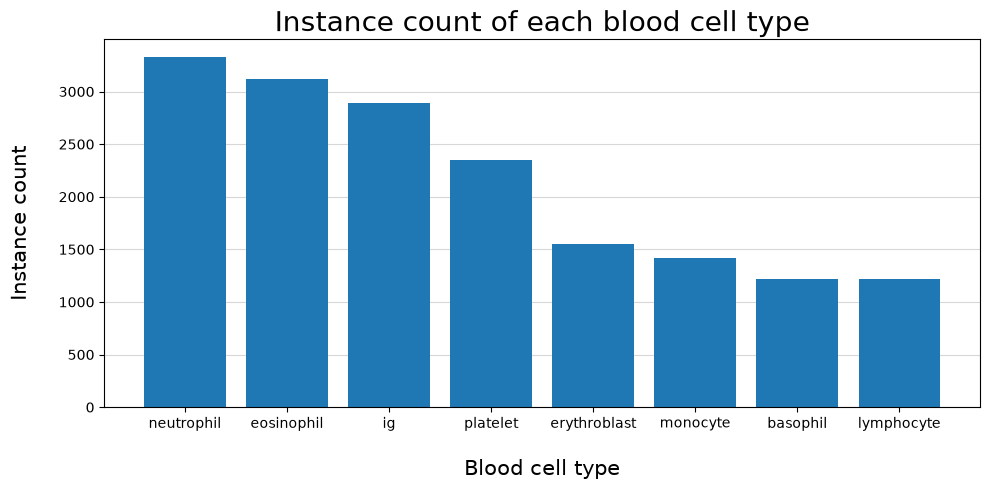

In [214]:
tags, count = zip(*types.most_common())

plt.style.use("default")
fig, ax = plt.subplots(figsize=(10,5))

ax.bar(tags, count)
ax.set_title("Instance count of each blood cell type", fontsize=20)
ax.set_xlabel("Blood cell type", labelpad=20, fontsize=15)
ax.set_ylabel("Instance count", labelpad=20, fontsize=15)
ax.yaxis.grid(True, alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Color mode

In [115]:
color_mode = []
for type in DATA_PATH.iterdir():
    for image in type.iterdir():
        with Image.open(image) as img:
            color_mode.append(img.mode)

color_mode = Counter(color_mode)

In [ ]:
# all images are rgb
for mode, count in color_mode.most_common():
    print(f"{mode}: {count}")

RGB: 17092


## Basic statistics

### Resolution distribution

In [127]:
# verify images format
resolutions = []
bpps = []

for tag in DATA_PATH.iterdir():
    for image in tag.iterdir():
        size = image.stat().st_size
        with Image.open(image) as img:
            w, h = img.size
            resolutions.append((w, h))
            bpps.append(size / (w * h))

resolutions = Counter(resolutions)

In [125]:
# the images have resolution variances but are overall similar (no image is smaller than 224x224)
for resolution, count in resolutions.most_common():
    print(f"{resolution[0]}x{resolution[1]}: {count}")

360x363: 16639
366x369: 250
360x360: 198
360x361: 2
362x360: 1
359x360: 1
361x360: 1


### Byte per pixel

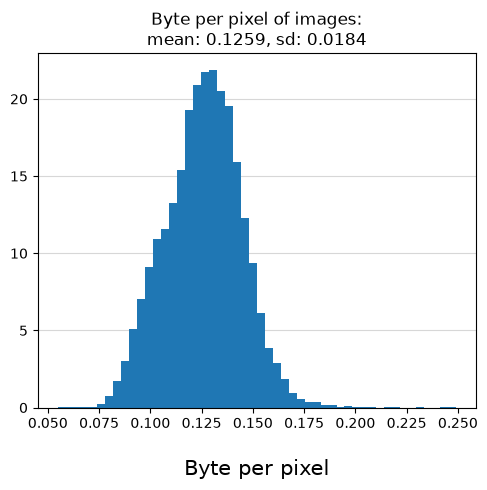

In [160]:
# No  spikes around zero, images seems overall healthy
bpp_mean = sum(bpps) / len(bpps)
bpp_sd = math.sqrt(((np.array(bpps) - bpp_mean)**2).sum(axis=0) / len(bpps))

plt.style.use("default")
fig, ax = plt.subplots(figsize=(5, 5))

ax.hist(bpps, density=True, bins=50)
ax.set_title(f"Byte per pixel of images:\nmean: {bpp_mean:.4f}, sd: {bpp_sd:.4f}")
ax.set_xlabel("Byte per pixel", labelpad=20, fontsize=15)
ax.yaxis.grid(True, alpha=0.5)
ax.set_axisbelow(True)


plt.tight_layout()
plt.show()

### Color and Brightness analysis

In [52]:
# verify images format
reds = {}
greens = {}
blues = {}
total = {}

for subdir in DATA_PATH.iterdir():
    tag = subdir.name

    for image in subdir.iterdir():
        with Image.open(image) as img:
            a = np.asarray(img)
            channel_mean = a.reshape(-1, 3).mean(axis=0)
            channel_sd = a.reshape(-1, 3).std(axis=0)
            total_mean = a.reshape(-1).mean(axis=0)
            total_sd = a.reshape(-1).std(axis=0)
            reds.setdefault(tag, {}).setdefault("mean", []).append(channel_mean[0])
            reds.setdefault(tag, {}).setdefault("std", []).append(channel_sd[0])
            greens.setdefault(tag, {}).setdefault("mean", []).append(channel_mean[1])
            greens.setdefault(tag, {}).setdefault("std", []).append(channel_sd[1])
            blues.setdefault(tag, {}).setdefault("mean", []).append(channel_mean[2])
            blues.setdefault(tag, {}).setdefault("std", []).append(channel_sd[2])
            total.setdefault(tag, {}).setdefault("mean", []).append(total_mean)
            total.setdefault(tag, {}).setdefault("std", []).append(total_sd)

#### Red channel

##### Bulk analysis

In [137]:
means = []
stds = []

for tag, data in reds.items():
    means.extend(data["mean"])
    stds.extend(data["std"])

means = np.array(means)
stds = np.array(stds)

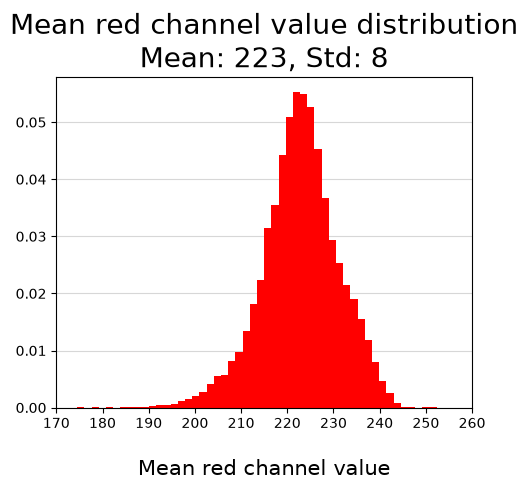

In [138]:
plt.style.use("default")
fig, ax = plt.subplots(figsize=(5, 5))

ax.hist(means, density=True, bins=50, color="red")
ax.set_title(f"Mean red channel value distribution\nMean: {means.mean(axis=0):.0f}, Std: {means.std(axis=0):.0f}", fontsize=20)
ax.set_xlabel("Mean red channel value", labelpad=20, fontsize=15)
ax.set_xlim(170, 260)
ax.yaxis.grid(True, alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

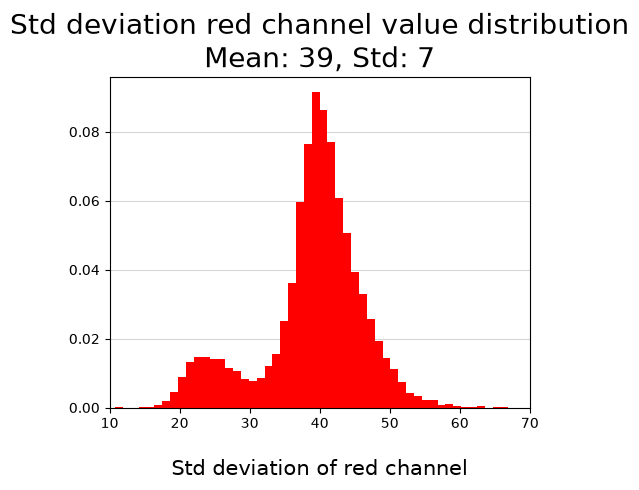

In [140]:
plt.style.use("default")
fig, ax = plt.subplots(figsize=(5, 5))

ax.hist(stds, density=True, bins=50, color="red")
ax.set_title(f"Std deviation red channel value distribution\nMean: {stds.mean(axis=0):.0f}, Std: {stds.std(axis=0):.0f}", fontsize=20)
ax.set_xlabel("Std deviation of red channel", labelpad=20, fontsize=15)
ax.set_xlim(10, 70)
ax.yaxis.grid(True, alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

##### Per class analysis

In [141]:
means = []
stds = []
tags = []

for tag, data in reds.items():
    tags.append(tag)
    means.append(np.array(data["mean"]))
    stds.append(np.array(data["std"]))

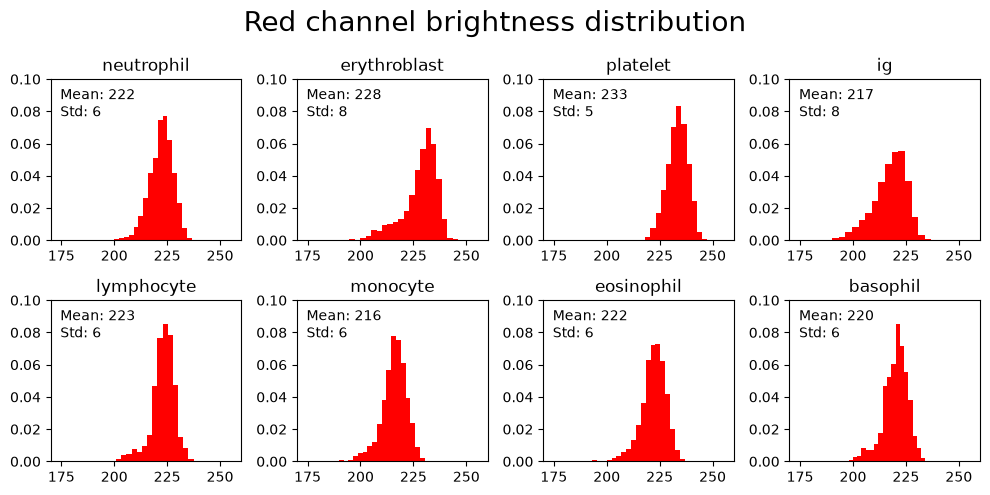

In [142]:
plt.style.use("default")
fig, axes = plt.subplots(figsize=(10, 5),ncols=4, nrows=2)

for ax, mean, tag in zip(axes.flat, means, tags):
    ax.hist(mean, density=True, bins=20, color="red")
    ax.set_title(f"{tag}")
    ax.text(
        0.05, 0.95,
        f"Mean: {mean.mean(axis=0):.0f}\nStd: {mean.std(axis=0):.0f}",
        transform=ax.transAxes,
        ha="left",
        va="top"
    )
    ax.set_ylim(None, 0.1)
    ax.set_xlim(170, 260)

plt.suptitle("Red channel brightness distribution", fontsize=20)

plt.tight_layout()
plt.show()

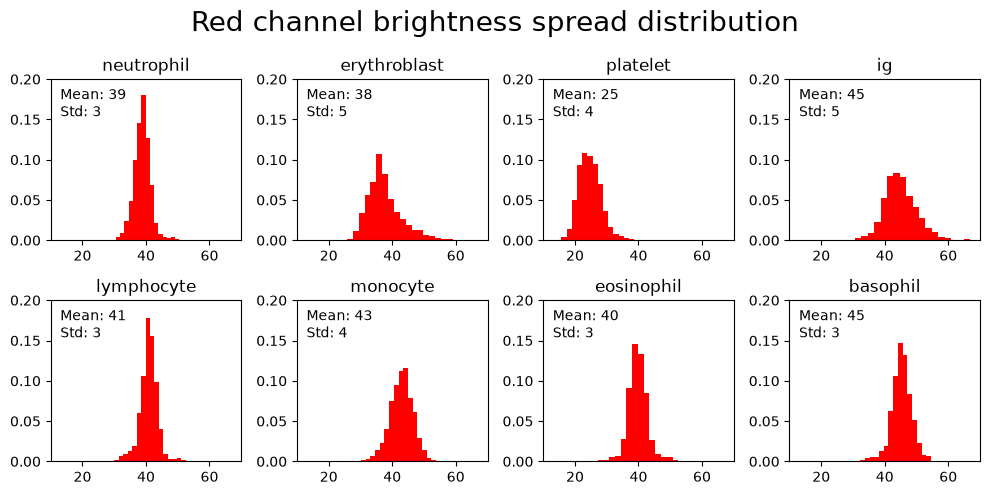

In [143]:
plt.style.use("default")
fig, axes = plt.subplots(figsize=(10, 5),ncols=4, nrows=2)

for ax, std, tag in zip(axes.flat, stds, tags):
    ax.hist(std, density=True, bins=20, color="red")
    ax.set_title(f"{tag}")
    ax.text(
        0.05, 0.95,
        f"Mean: {std.mean(axis=0):.0f}\nStd: {std.std(axis=0):.0f}",
        transform=ax.transAxes,
        ha="left",
        va="top"
    )
    ax.set_ylim(None, 0.2)
    ax.set_xlim(10, 70)

plt.suptitle("Red channel brightness spread distribution", fontsize=20)

plt.tight_layout()
plt.show()

#### Green channel

##### Bulk analysis

In [165]:
means = []
stds = []

for tag, data in greens.items():
    means.extend(data["mean"])
    stds.extend(data["std"])

means = np.array(means)
stds = np.array(stds)

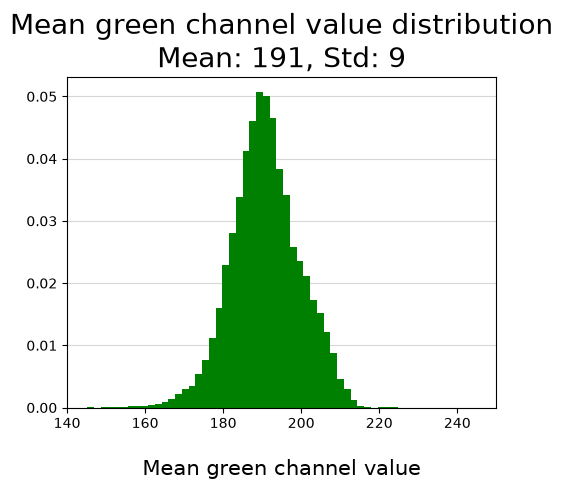

In [166]:
plt.style.use("default")
fig, ax = plt.subplots(figsize=(5, 5))

ax.hist(means, density=True, bins=50, color="green")
ax.set_title(f"Mean green channel value distribution\nMean: {means.mean(axis=0):.0f}, Std: {means.std(axis=0):.0f}", fontsize=20)
ax.set_xlabel("Mean green channel value", labelpad=20, fontsize=15)
ax.set_xlim(140, 250)
ax.yaxis.grid(True, alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

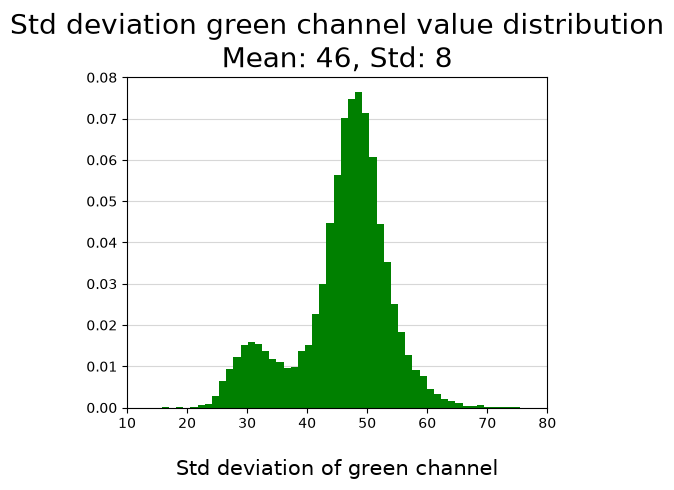

In [167]:
plt.style.use("default")
fig, ax = plt.subplots(figsize=(5, 5))

ax.hist(stds, density=True, bins=50, color="green")
ax.set_title(f"Std deviation green channel value distribution\nMean: {stds.mean(axis=0):.0f}, Std: {stds.std(axis=0):.0f}", fontsize=20)
ax.set_xlabel("Std deviation of green channel", labelpad=20, fontsize=15)
ax.set_xlim(10, 80)
ax.yaxis.grid(True, alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

##### Per class analysis

In [177]:
means = []
stds = []
tags = []

for tag, data in greens.items():
    tags.append(tag)
    means.append(np.array(data["mean"]))
    stds.append(np.array(data["std"]))

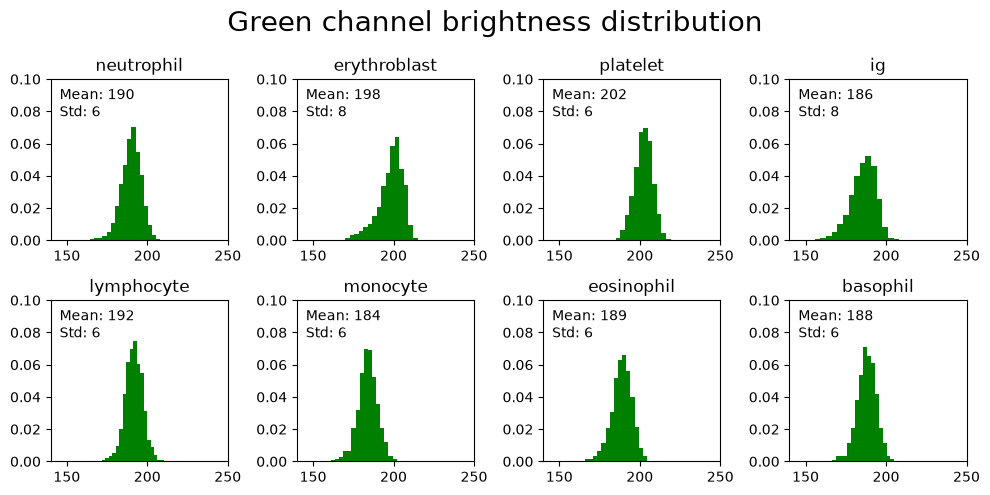

In [178]:
plt.style.use("default")
fig, axes = plt.subplots(figsize=(10, 5),ncols=4, nrows=2)

for ax, mean, tag in zip(axes.flat, means, tags):
    ax.hist(mean, density=True, bins=20, color="green")
    ax.set_title(f"{tag}")
    ax.text(
        0.05, 0.95,
        f"Mean: {mean.mean(axis=0):.0f}\nStd: {mean.std(axis=0):.0f}",
        transform=ax.transAxes,
        ha="left",
        va="top"
    )
    ax.set_ylim(None, 0.1)
    ax.set_xlim(140, 250)

plt.suptitle("Green channel brightness distribution", fontsize=20)

plt.tight_layout()
plt.show()

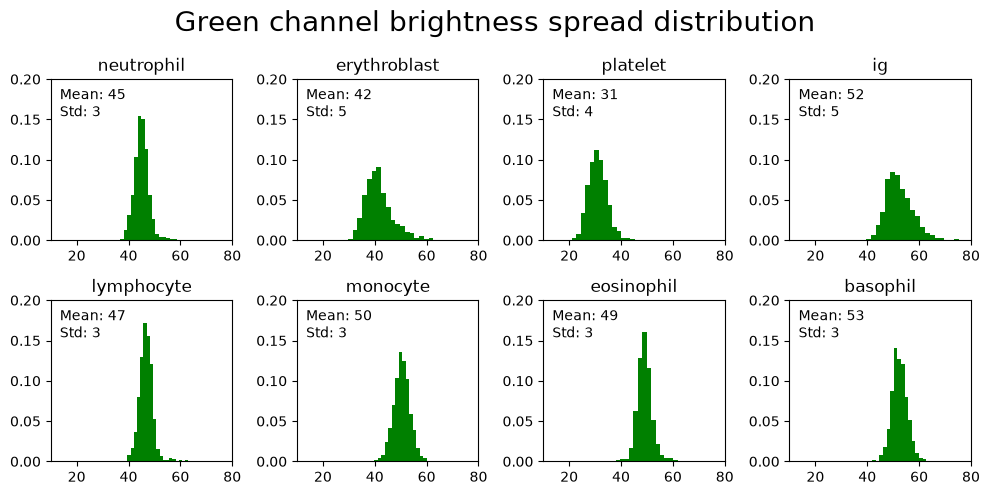

In [179]:
plt.style.use("default")
fig, axes = plt.subplots(figsize=(10, 5),ncols=4, nrows=2)

for ax, std, tag in zip(axes.flat, stds, tags):
    ax.hist(std, density=True, bins=20, color="green")
    ax.set_title(f"{tag}")
    ax.text(
        0.05, 0.95,
        f"Mean: {std.mean(axis=0):.0f}\nStd: {std.std(axis=0):.0f}",
        transform=ax.transAxes,
        ha="left",
        va="top"
    )
    ax.set_ylim(None, 0.2)
    ax.set_xlim(10, 80)

plt.suptitle("Green channel brightness spread distribution", fontsize=20)

plt.tight_layout()
plt.show()

#### Blue channel

#### bulk analysis

In [171]:
means = []
stds = []

for tag, data in blues.items():
    means.extend(data["mean"])
    stds.extend(data["std"])

means = np.array(means)
stds = np.array(stds)

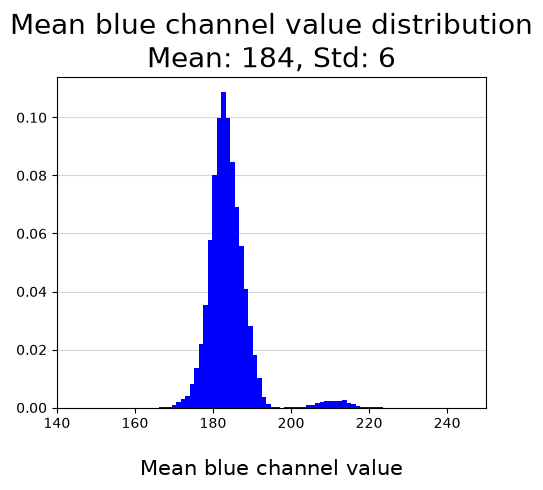

In [172]:
plt.style.use("default")
fig, ax = plt.subplots(figsize=(5, 5))

ax.hist(means, density=True, bins=50, color="blue")
ax.set_title(f"Mean blue channel value distribution\nMean: {means.mean(axis=0):.0f}, Std: {means.std(axis=0):.0f}", fontsize=20)
ax.set_xlabel("Mean blue channel value", labelpad=20, fontsize=15)
ax.set_xlim(140, 250)
ax.yaxis.grid(True, alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

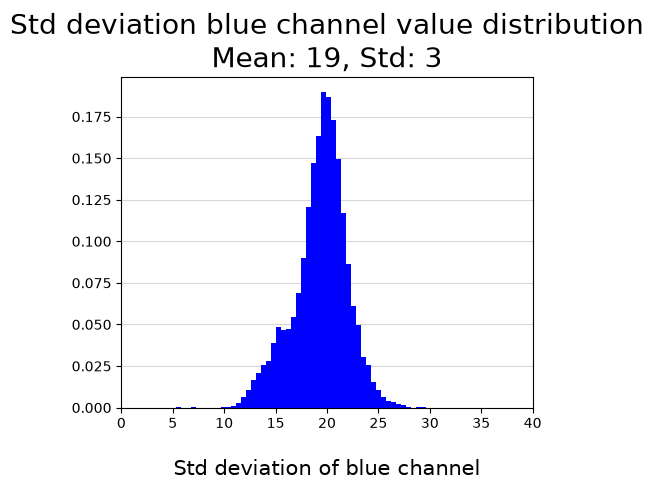

In [176]:
plt.style.use("default")
fig, ax = plt.subplots(figsize=(5, 5))

ax.hist(stds, density=True, bins=50, color="blue")
ax.set_title(f"Std deviation blue channel value distribution\nMean: {stds.mean(axis=0):.0f}, Std: {stds.std(axis=0):.0f}", fontsize=20)
ax.set_xlabel("Std deviation of blue channel", labelpad=20, fontsize=15)
ax.set_xlim(0, 40)
ax.yaxis.grid(True, alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

##### Per class analysis

In [198]:
means = []
stds = []
tags = []

for tag, data in blues.items():
    tags.append(tag)
    means.append(np.array(data["mean"]))
    stds.append(np.array(data["std"]))

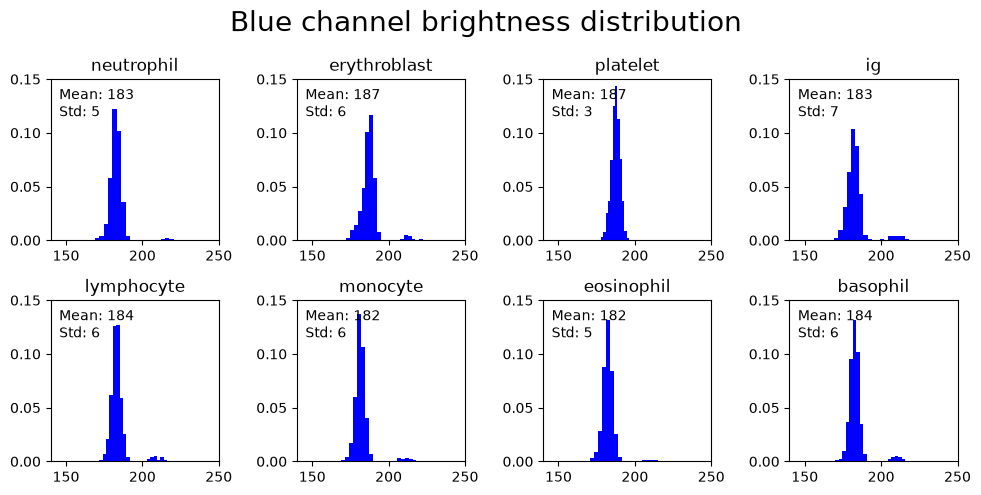

In [199]:
plt.style.use("default")
fig, axes = plt.subplots(figsize=(10, 5),ncols=4, nrows=2)

for ax, mean, tag in zip(axes.flat, means, tags):
    ax.hist(mean, density=True, bins=20, color="blue")
    ax.set_title(f"{tag}")
    ax.text(
        0.05, 0.95,
        f"Mean: {mean.mean(axis=0):.0f}\nStd: {mean.std(axis=0):.0f}",
        transform=ax.transAxes,
        ha="left",
        va="top"
    )
    ax.set_ylim(None, 0.15)
    ax.set_xlim(140, 250)

plt.suptitle("Blue channel brightness distribution", fontsize=20)

plt.tight_layout()
plt.show()

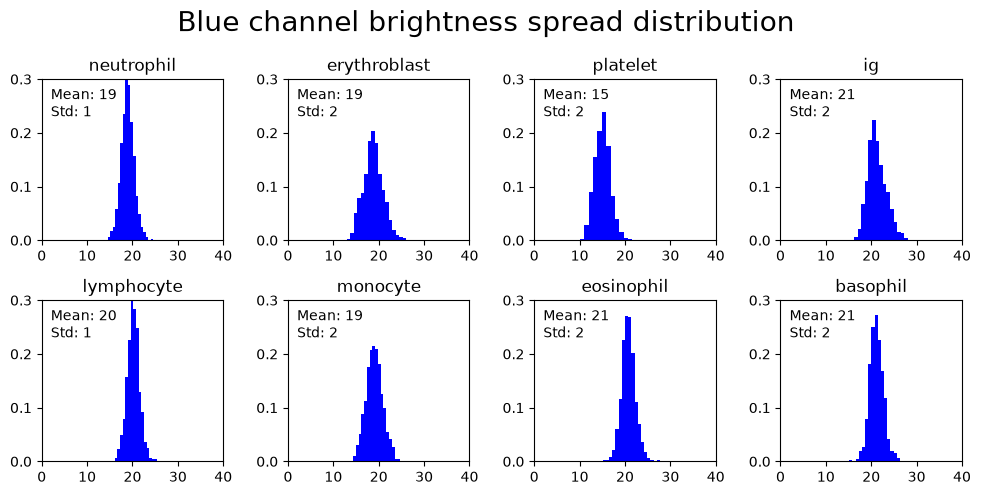

In [200]:
plt.style.use("default")
fig, axes = plt.subplots(figsize=(10, 5),ncols=4, nrows=2)

for ax, std, tag in zip(axes.flat, stds, tags):
    ax.hist(std, density=True, bins=20, color="blue")
    ax.set_title(f"{tag}")
    ax.text(
        0.05, 0.95,
        f"Mean: {std.mean(axis=0):.0f}\nStd: {std.std(axis=0):.0f}",
        transform=ax.transAxes,
        ha="left",
        va="top"
    )
    ax.set_ylim(None, 0.3)
    ax.set_xlim(0, 40)

plt.suptitle("Blue channel brightness spread distribution", fontsize=20)

plt.tight_layout()
plt.show()

#### Total brightness

##### Bulk analysis

In [216]:
means = []
stds = []

for tag, data in total.items():
    means.extend(data["mean"])
    stds.extend(data["std"])

means = np.array(means)
stds = np.array(stds)

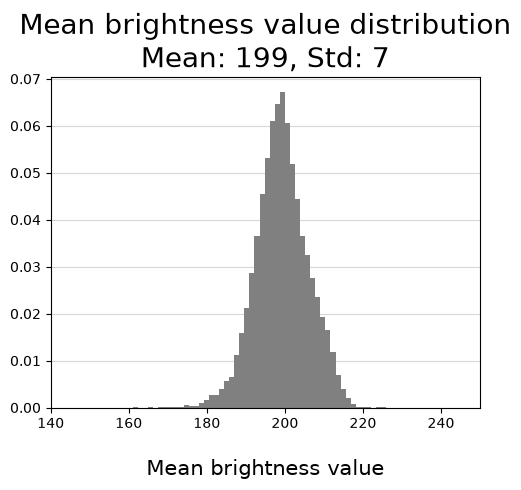

In [217]:
plt.style.use("default")
fig, ax = plt.subplots(figsize=(5, 5))

ax.hist(means, density=True, bins=50, color="grey")
ax.set_title(f"Mean brightness value distribution\nMean: {means.mean(axis=0):.0f}, Std: {means.std(axis=0):.0f}", fontsize=20)
ax.set_xlabel("Mean brightness value", labelpad=20, fontsize=15)
ax.set_xlim(140, 250)
ax.yaxis.grid(True, alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

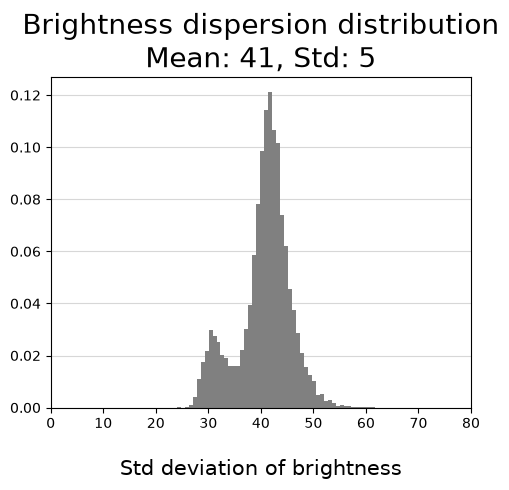

In [218]:
plt.style.use("default")
fig, ax = plt.subplots(figsize=(5, 5))

ax.hist(stds, density=True, bins=50, color="grey")
ax.set_title(f"Brightness dispersion distribution\nMean: {stds.mean(axis=0):.0f}, Std: {stds.std(axis=0):.0f}", fontsize=20)
ax.set_xlabel("Std deviation of brightness", labelpad=20, fontsize=15)
ax.set_xlim(0, 80)
ax.yaxis.grid(True, alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

##### Per class analysis

In [206]:
means = []
stds = []
tags = []

for tag, data in total.items():
    tags.append(tag)
    means.append(np.array(data["mean"]))
    stds.append(np.array(data["std"]))

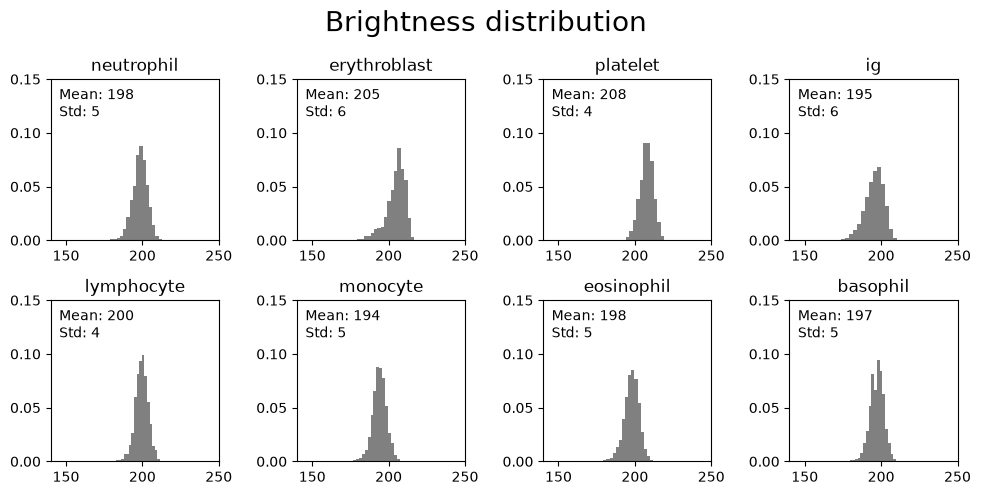

In [211]:
plt.style.use("default")
fig, axes = plt.subplots(figsize=(10, 5),ncols=4, nrows=2)

for ax, mean, tag in zip(axes.flat, means, tags):
    ax.hist(mean, density=True, bins=20, color="grey")
    ax.set_title(f"{tag}")
    ax.text(
        0.05, 0.95,
        f"Mean: {mean.mean(axis=0):.0f}\nStd: {mean.std(axis=0):.0f}",
        transform=ax.transAxes,
        ha="left",
        va="top"
    )
    ax.set_ylim(None, 0.15)
    ax.set_xlim(140, 250)

plt.suptitle("Brightness distribution", fontsize=20)

plt.tight_layout()
plt.show()

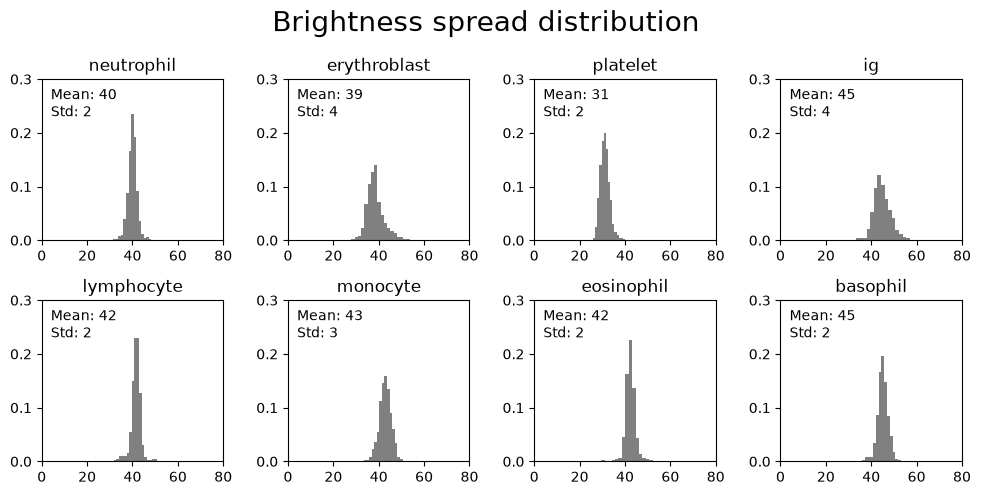

In [210]:
plt.style.use("default")
fig, axes = plt.subplots(figsize=(10, 5),ncols=4, nrows=2)

for ax, std, tag in zip(axes.flat, stds, tags):
    ax.hist(std, density=True, bins=20, color="grey")
    ax.set_title(f"{tag}")
    ax.text(
        0.05, 0.95,
        f"Mean: {std.mean(axis=0):.0f}\nStd: {std.std(axis=0):.0f}",
        transform=ax.transAxes,
        ha="left",
        va="top"
    )
    ax.set_ylim(None, 0.3)
    ax.set_xlim(0, 80)

plt.suptitle("Brightness spread distribution", fontsize=20)

plt.tight_layout()
plt.show()

## Visual analysis

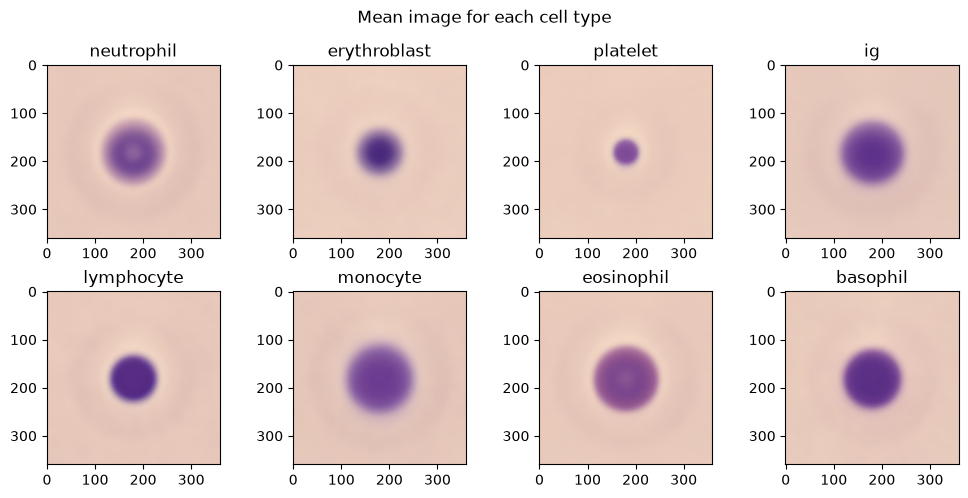

In [ ]:
from PIL.Image import LANCZOS

paths = list(DATA_PATH.iterdir())

plt.style.use("default")
fig, axis = plt.subplots(figsize=(10, 5), ncols=4, nrows=2)

for ax, path in zip(axis.flat, paths):
    tag = path.name
    images = [Image.open(image) for image in path.iterdir()]
    agg = np.zeros((360, 360, 3), dtype=np.float64)
    for image in images:
        agg += np.asarray(image.resize((360, 360), Image.LANCZOS), dtype=np.float64)

    agg /= len(images)

    ax.imshow(agg.astype(np.uint8))
    ax.set_title(f"{tag}")

plt.suptitle("Mean image for each cell type")
plt.tight_layout()
plt.show()

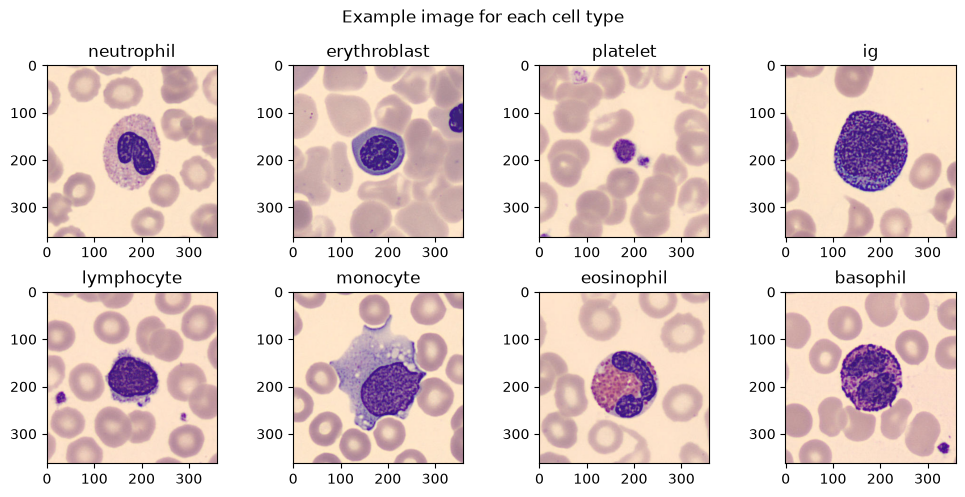

In [4]:
paths = list(DATA_PATH.iterdir())

plt.style.use("default")
fig, axis = plt.subplots(figsize=(10, 5), ncols=4, nrows=2)

for ax, path in zip(axis.flat, paths):
    tag = path.name
    img = Image.open(random.choice(list(path.iterdir())))
    ax.imshow(img)
    ax.set_title(f"{tag}")

plt.suptitle("Example image for each cell type")
plt.tight_layout()
plt.show()

### Sanity check of each cell type

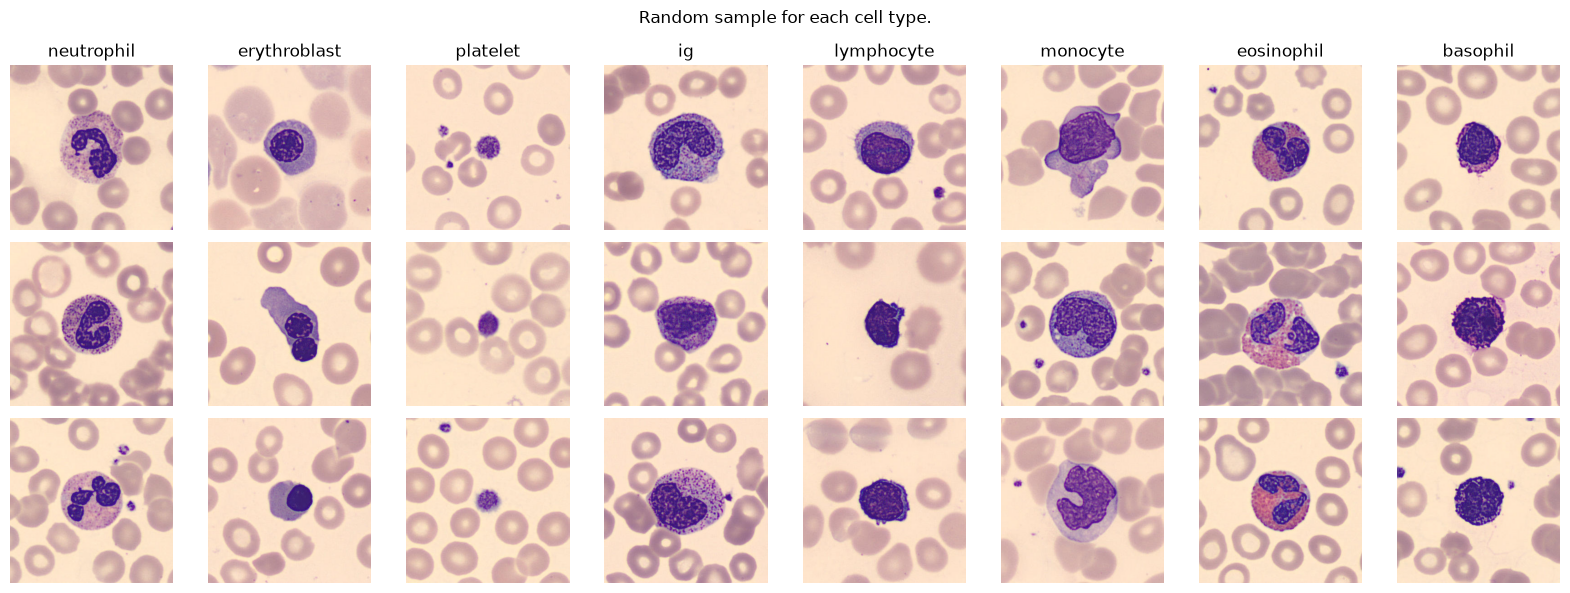

In [5]:
import random

sample_size = 3

plt.style.use("default")
fig, axis = plt.subplots(figsize=(16, sample_size*2), ncols=8, nrows=sample_size)

for i, path in enumerate(DATA_PATH.iterdir()):
    tag = path.name
    files = list(path.iterdir())
    sample = random.choices(files, k=sample_size)

    for j, file in enumerate(sample):
        image = Image.open(file)
        axis[j][i].imshow(image)
        axis[j][i].axis("off")
        if j == 0:
            axis[j][i].set_title(f"{tag}")

plt.suptitle("Random sample for each cell type.")
plt.tight_layout()
plt.show()

## Embedding-based exploration

In [103]:
from transformers import AutoImageProcessor, AutoModel, AutoModelForImageClassification, TorchAoConfig
from typing import Any
from torchvision.io import read_image, ImageReadMode
from transformers import DetrImageProcessor
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.v2.functional as F
from tqdm import tqdm

### Set up embedding model and preprocessor

In [56]:
device = "cuda" if torch.cuda.is_available() else "cpu"
processor = AutoImageProcessor.from_pretrained('facebook/dinov2-base')
model = AutoModel.from_pretrained('facebook/dinov2-base').to(device)

Loading weights: 100%|██████████| 223/223 [00:03<00:00, 72.02it/s]


### Create a custom image dataset

In [ ]:
class ImageDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        try:
            # when an item is retrieved this ensures it gets loaded from it path and resized to a convinient resolution
            image = F.resize(read_image(self.paths[i], mode=ImageReadMode.RGB), [224, 224], antialias=True)
            # Additionally this snipet preprocess the image 
            input = processor(
                images=image,
                return_tensors="pt",
                do_resize=False,
                do_center_crop=False
            )["pixel_values"][0]
            return input
        except Exception as e:
            print(f"Skiping {self.paths[i]}: {e}")
            return None

### Load data

In [57]:
data = []

for subdir in DATA_PATH.iterdir():
    cell_type = subdir.name
    for image_path in subdir.iterdir():
        data.append((str(image_path), cell_type))

In [ ]:
def collate(batch):
    batch = [b for b in batch if b is not None]
    if not batch:
        return None
    return torch.stack(batch)


loader = DataLoader(
    ImageDataset([image[0] for image in data]),
    batch_size=64,
    num_workers=4,
    collate_fn=collate,
    pin_memory=True
)

### Process images

In [ ]:
outputs = []

with torch.inference_mode():
    for batch in tqdm(loader, desc="processing batches", unit="batch"):
        if batch is None:
            continue

        output = model(pixel_values=batch.to(device))
        emb = output.pooler_output
        emb = torch.nn.functional.normalize(emb, dim=-1).cpu().numpy()

        outputs.append(emb)
outputs = np.stack([embedding for batch in outputs for embedding in batch])

processing batches: 100%|██████████| 268/268 [07:07<00:00,  1.60s/batch]


In [ ]:
unique_labels = set(item[1] for item in data)
labels_to_index = {label: i for i, label in enumerate(unique_labels)}
index_to_labels = {i: label for label, i in labels_to_index.items()}
labels = np.array([labels_to_index[item[1]] for item in data])

### Reduce dimensionality of embeddings to 2 using PCA

In [201]:
from sklearn.decomposition import PCA

reducer = PCA(n_components=2)
reduced = reducer.fit_transform(outputs)

#### Plot reduced embeddings

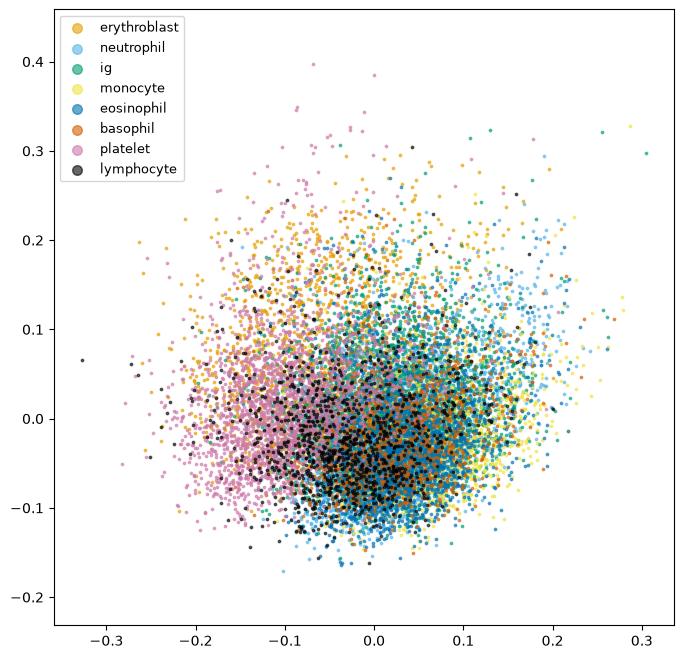

In [202]:
plt.style.use("default")
plt.figure(figsize=(8, 8))

colors = ["#E69F00", "#56B4E9", "#009E73", "#F0E442",
          "#0072B2", "#D55E00", "#CC79A7", "#000000"]

for i in range(len(unique_labels)):
    indexes = labels == i
    plt.scatter(reduced[indexes, 0], reduced[indexes, 1], s=3, alpha=0.6, color=colors[i], label=index_to_labels[i])

plt.legend(markerscale=4, fontsize=9)
plt.axis("equal")
plt.show()

### Reduce dimensionality of embeddings to 2 using UMAP

In [217]:
from umap import UMAP

reducer = UMAP(n_neighbors=15, min_dist=0.1, metric="euclidean")
reduced = reducer.fit_transform(outputs)

#### Plot reduced embeddings

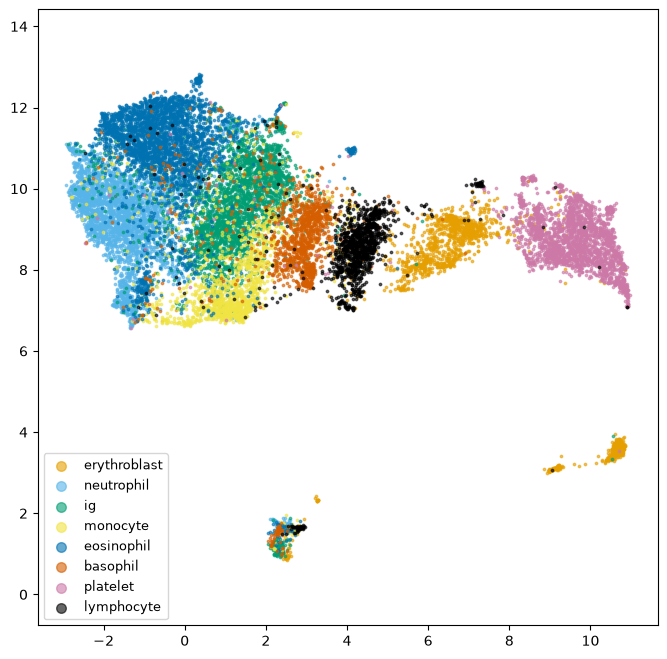

In [218]:
plt.style.use("default")
plt.figure(figsize=(8, 8))

colors = ["#E69F00", "#56B4E9", "#009E73", "#F0E442",
          "#0072B2", "#D55E00", "#CC79A7", "#000000"]

for i in range(len(unique_labels)):
    indexes = labels == i
    plt.scatter(reduced[indexes, 0], reduced[indexes, 1], s=3, alpha=0.6, color=colors[i], label=index_to_labels[i])

plt.legend(markerscale=4, fontsize=9)
plt.axis("equal")
plt.show()

#### Zooming on the two islands observed on the UMAP reduced embedding analysis

In [260]:
y_below_six = reduced[:, 1] < 6
y_above_six = reduced[:, 1] > 6
x_below_six = reduced[:, 0] < 6
x_above_six = reduced[:, 0] > 6
left = np.array(data)[np.where(y_below_six & x_below_six)[0]]
right = np.array(data)[np.where(y_below_six & x_above_six)[0]]
bulk = np.array(data)[np.where(y_above_six)[0]]

In [271]:
Counter(left[:, 1])

Counter({np.str_('ig'): 151,
         np.str_('erythroblast'): 52,
         np.str_('lymphocyte'): 50,
         np.str_('basophil'): 50,
         np.str_('monocyte'): 49,
         np.str_('neutrophil'): 48,
         np.str_('eosinophil'): 48})

In [307]:
def probe_island(island, title="island sample"):
    for label in unique_labels:
        island_sample = island[island[:, 1] == label]
        if len(island_sample) == 0:
            print(f"No image of {label} in island")
            continue
        bulk_sample = bulk[bulk[:, 1] == label]

        n = min(len(island_sample), 4)

        np.random.seed(42)
        island_sample = island_sample[np.random.choice(len(island_sample), size=n, replace=False)]
        island_sample = [Image.open(path) for path in island_sample[:, 0]]
        bulk_sample = bulk_sample[np.random.choice(len(bulk_sample), size=n, replace=False)]
        bulk_sample = [Image.open(path) for path in bulk_sample[:, 0]]

        plt.style.use("default")
        fig, axis = plt.subplots(figsize=(10, 5), ncols=2 if n == 1 else 4, nrows=1 if n <= 2 else 2)

        images = []
        images.extend(bulk_sample)
        images.extend(island_sample)
        for i, (img, ax) in enumerate(zip(images, axis.flat)):
            ax.imshow(img)
            if i == 0:
                ax.set_title("Main bulk sample")
            elif i == n:
                ax.set_title(title)

        plt.suptitle(f"{label}")
        plt.tight_layout()
        plt.show()

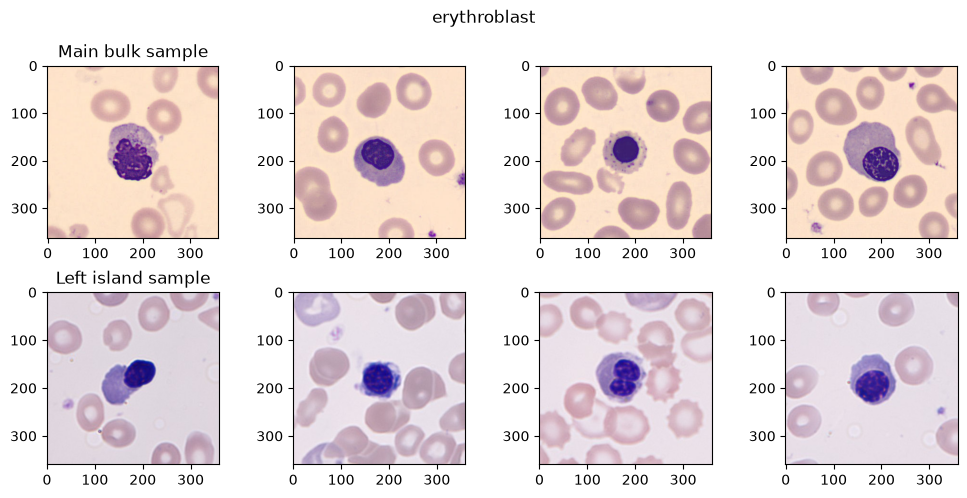

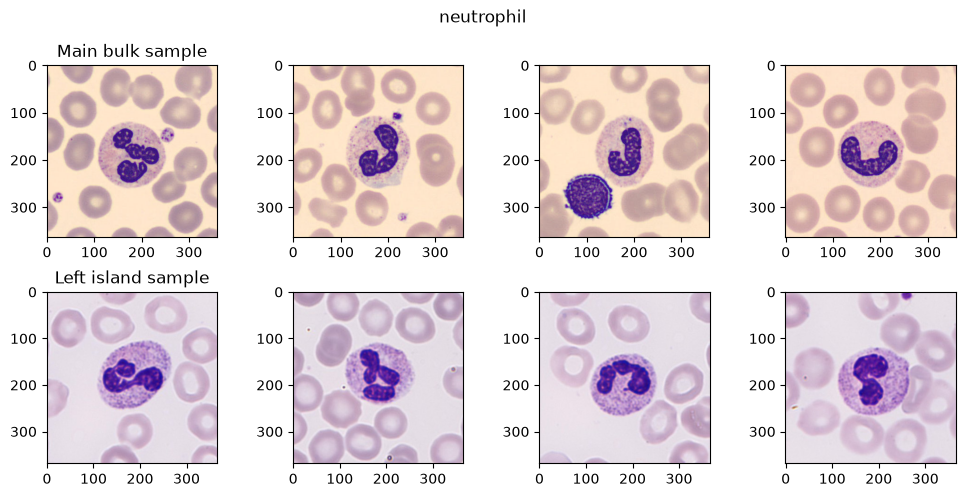

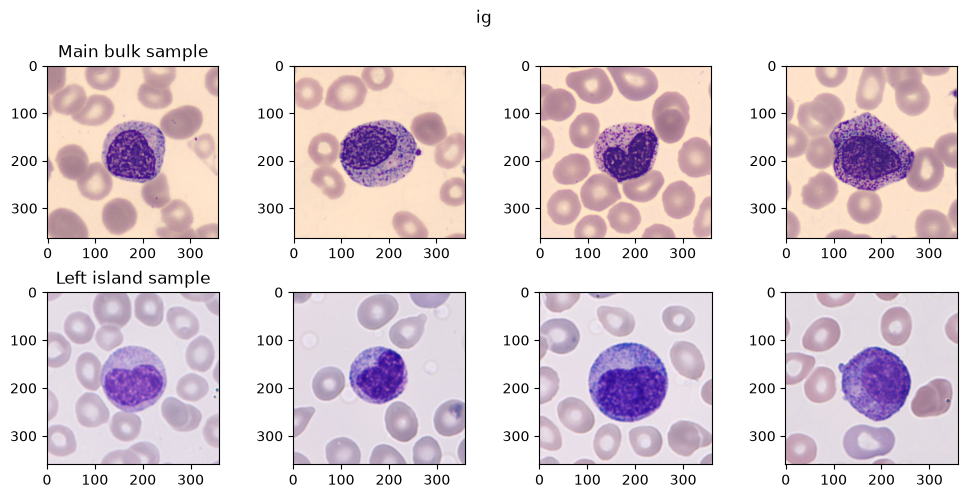

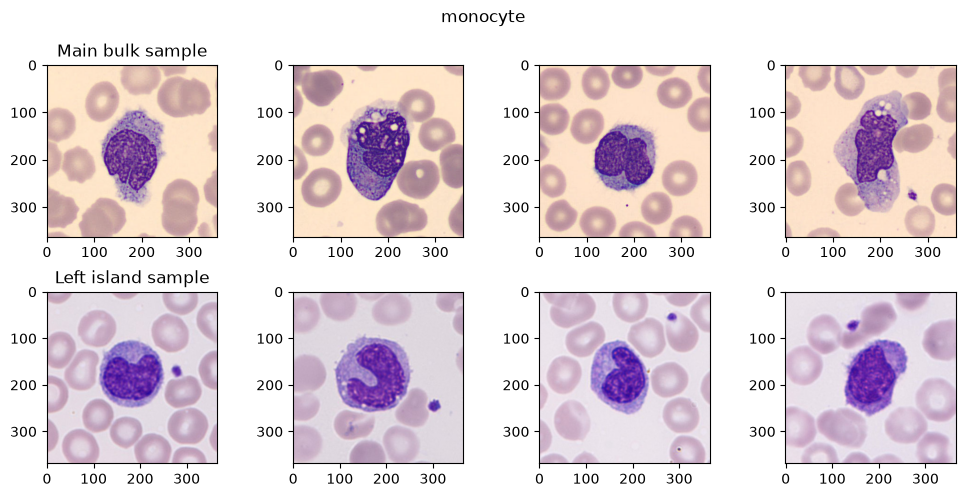

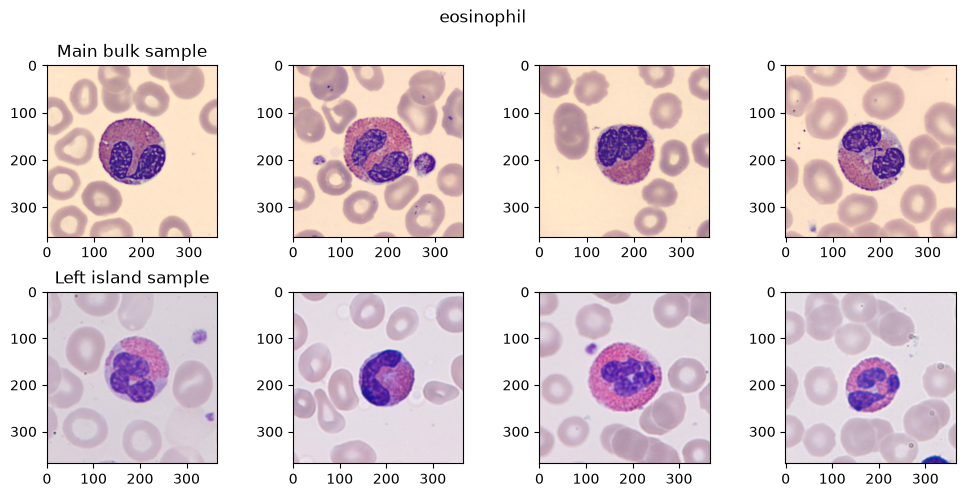

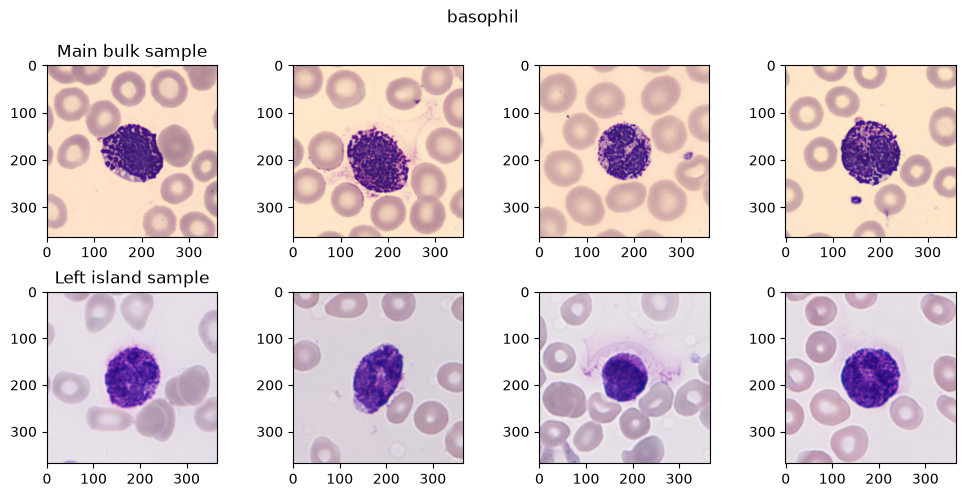

No image of platelet in island


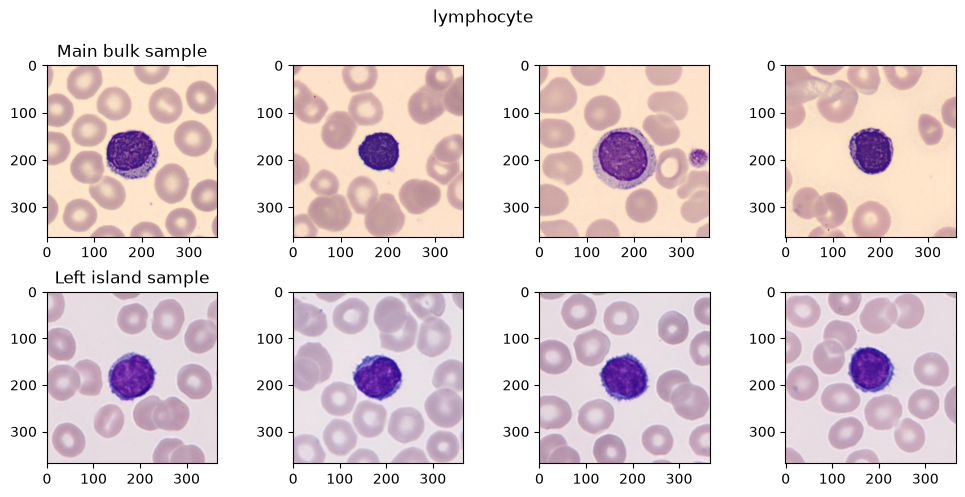

In [309]:
probe_island(left, "Left island sample")

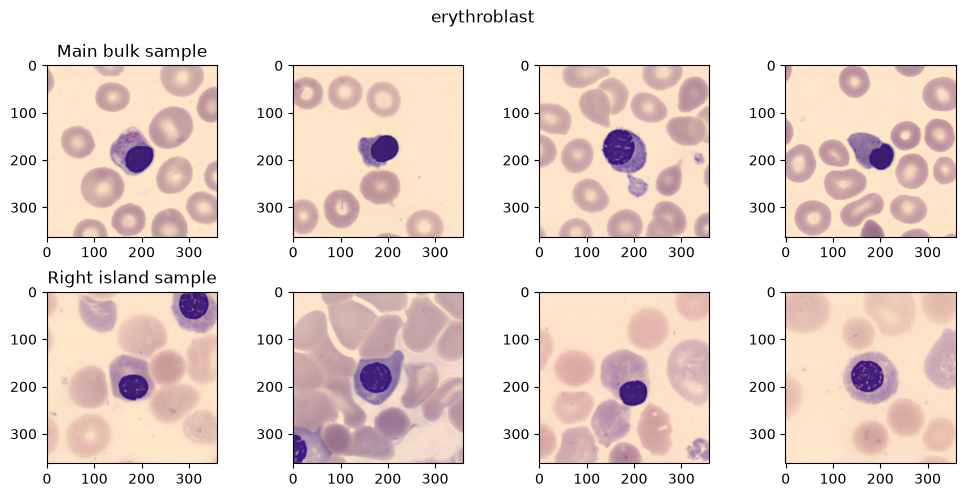

No image of neutrophil in island


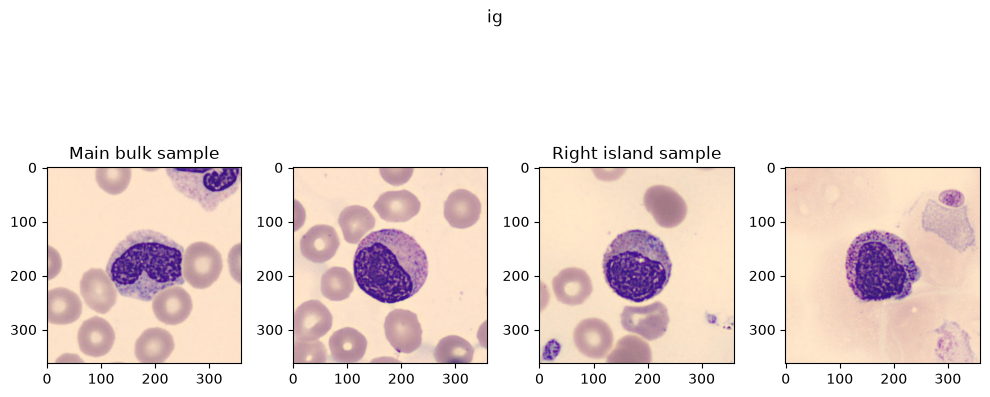

No image of monocyte in island
No image of eosinophil in island
No image of basophil in island


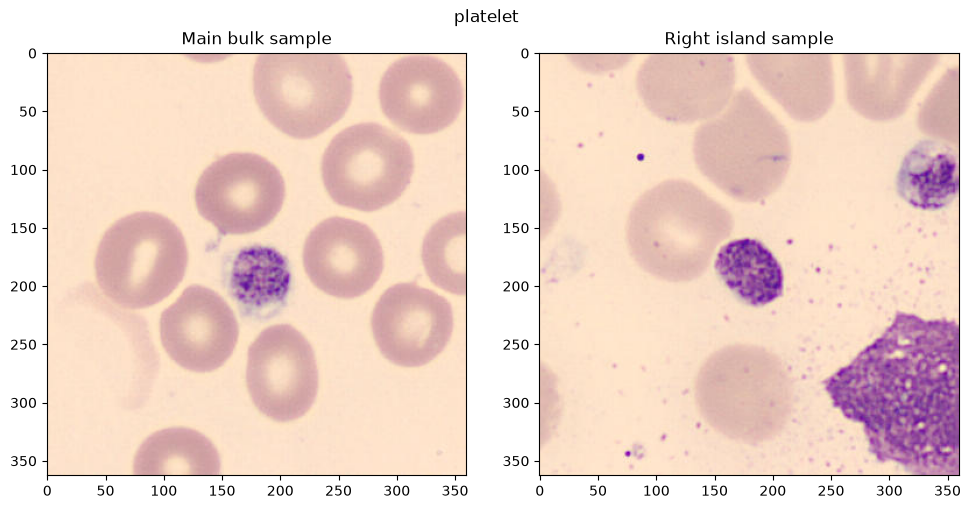

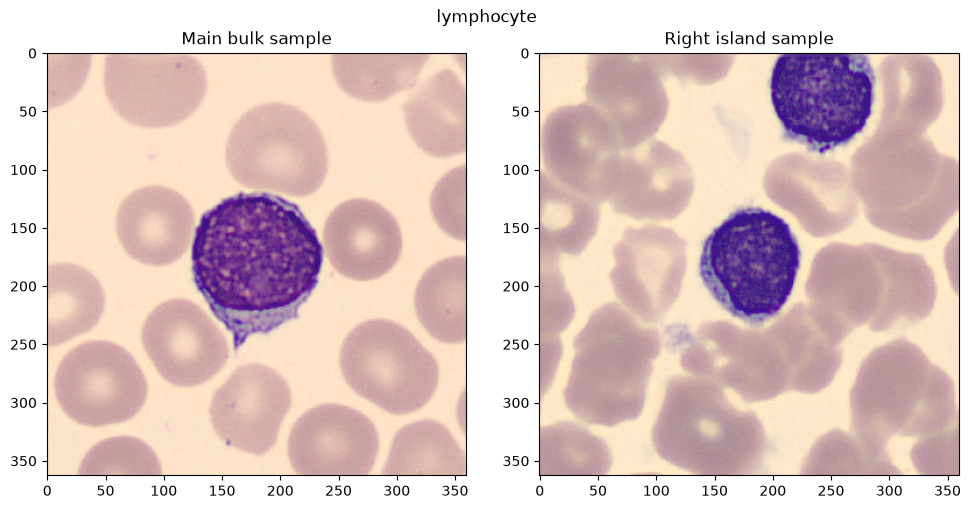

In [310]:
probe_island(right, "Right island sample")

In [311]:
import gc
import torch

def clean_memory():
    gc.collect()                       # free unreachable Python objects
    if torch.cuda.is_available():
        torch.cuda.synchronize()       # wait for pending GPU work
        torch.cuda.empty_cache()       # release cached GPU blocks to the driver
        torch.cuda.ipc_collect()       # clean up leftover inter-process memory
        print(f"GPU allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB | "
              f"reserved: {torch.cuda.memory_reserved() / 1e9:.2f} GB")

clean_memory()

GPU allocated: 0.55 GB | reserved: 0.65 GB
